# Instructor Effectiveness Modeling

## Problem Understanding

The objective of this project is to estimate instructor effectiveness using learner outcomes, engagement metrics, and learner feedback.

Each row in the dataset represents one course batch, and an instructor may teach multiple batches. Therefore, the analysis first examines batch-level performance and then aggregates the information to the instructor level.

An Instructor Effectiveness Score is created using relevant performance, engagement, and feedback metrics. The score is then converted into three effectiveness tiers: Low, Medium, and High.

Finally, machine learning models are used to predict the effectiveness tier of an instructor.

In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


## Libraries

The following Python libraries are used for data manipulation, numerical calculations, visualization, and machine learning.


In [ ]:
file_id = "1PFja1WUMPMIw7c0e962vKFMjBKciUGSk"

url = f"https://drive.google.com/uc?id={file_id}"

df = pd.read_csv(url)

## Dataset Overview

The dataset contains batch-level information about instructors, courses, learner outcomes, learner engagement, and feedback.

The identifier columns are `batch_id`, `instructor_id`, and `course_id`.

The remaining variables describe learner performance, engagement, and feedback and will be used during the analysis.


In [ ]:
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [ ]:
df.tail()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
1995,B_1131,I_047,C_17,0.589309,19.227979,46.242023,0.433437,0.848756,0.641781,0.261656,4.339478,0.643116
1996,B_1295,I_037,C_25,0.980000,36.737265,93.249093,0.103561,1.000000,0.688175,0.375195,4.912936,0.959988
1997,B_0861,I_033,C_06,0.531447,24.907878,83.990693,0.512266,0.918924,0.598276,0.271701,4.211113,0.773437
1998,B_1460,I_069,C_10,0.641025,22.395362,80.044231,0.317231,0.558183,0.575629,0.135500,4.182141,0.962627
1999,B_1127,I_045,C_22,0.300000,23.101794,86.891153,0.700000,0.563834,0.538691,0.210189,4.420309,0.545611


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [ ]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


## Missing Value Analysis

Missing values were checked across all columns.

The missing-value analysis helps determine whether preprocessing is required before performing statistical analysis and machine learning.

Where necessary, missing values are handled before model training so that the algorithms can work correctly.


In [ ]:
df.isnull().sum()

,0
batch_id,0
instructor_id,0
course_id,0
completion_rate,0
avg_score_improvement,0
avg_quiz_score,0
dropout_rate,0
avg_watch_time,0
assignment_submission_rate,0
forum_activity_rate,0


In [ ]:
df.duplicated().sum()

np.int64(0)

## Numerical Feature and Outlier Analysis

The numerical columns are identified separately from categorical columns so that appropriate visualizations can be applied.

Boxplots are used to examine the distribution of each numerical variable and identify potential outliers.

A boxplot shows the median, spread, and range of the data. Values that appear beyond the whiskers may indicate potential outliers or unusual observations.

Outliers are not automatically removed because an unusual value may represent a genuine batch-level observation. They should be investigated based on the context of the dataset before deciding whether any treatment is necessary.


In [ ]:
# visualization
numerical_columns = df.select_dtypes(include=['float64']).columns
object_column = df.select_dtypes(include = ['object']).columns

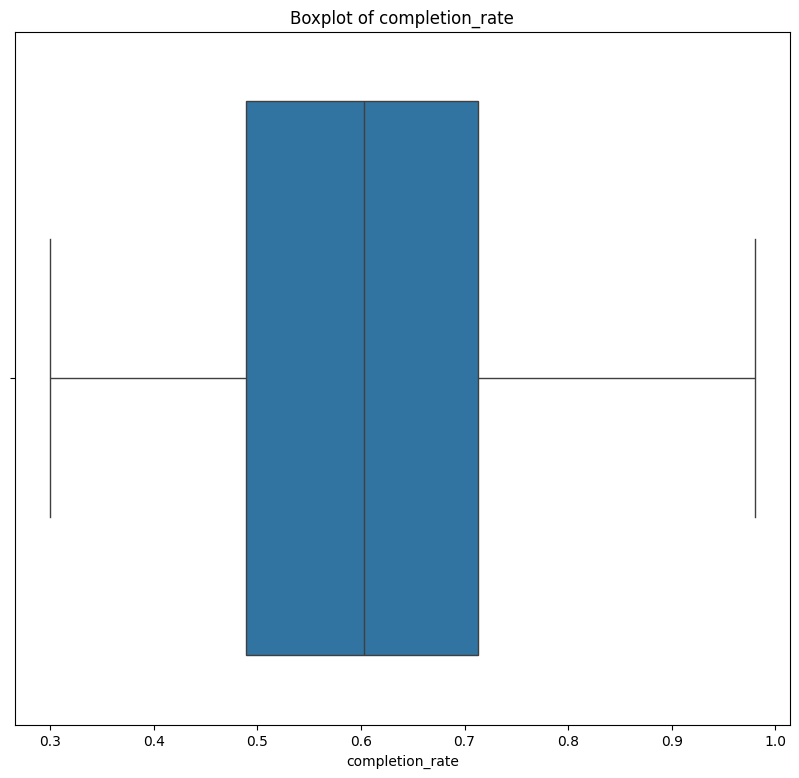

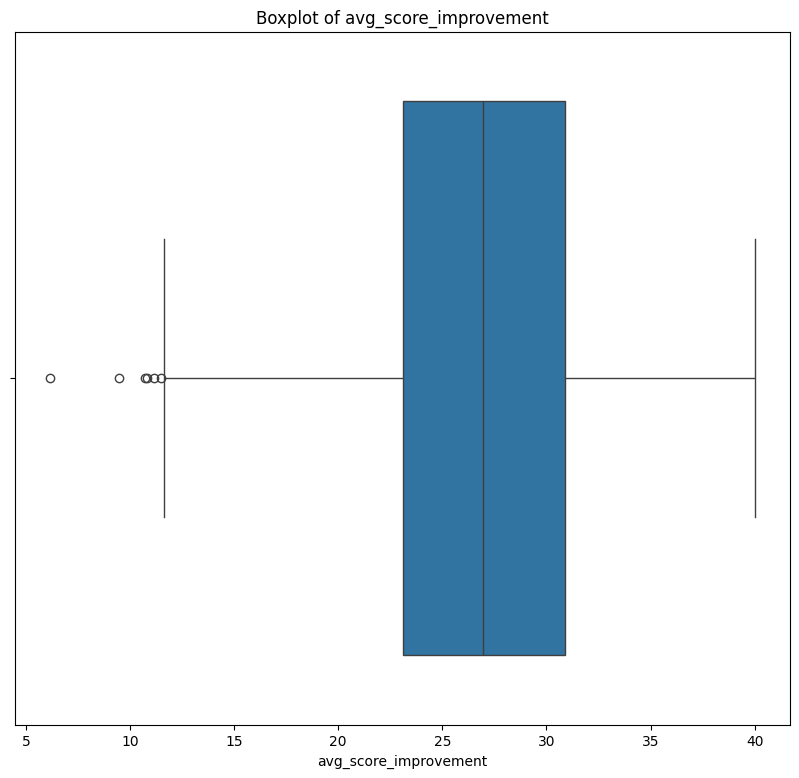

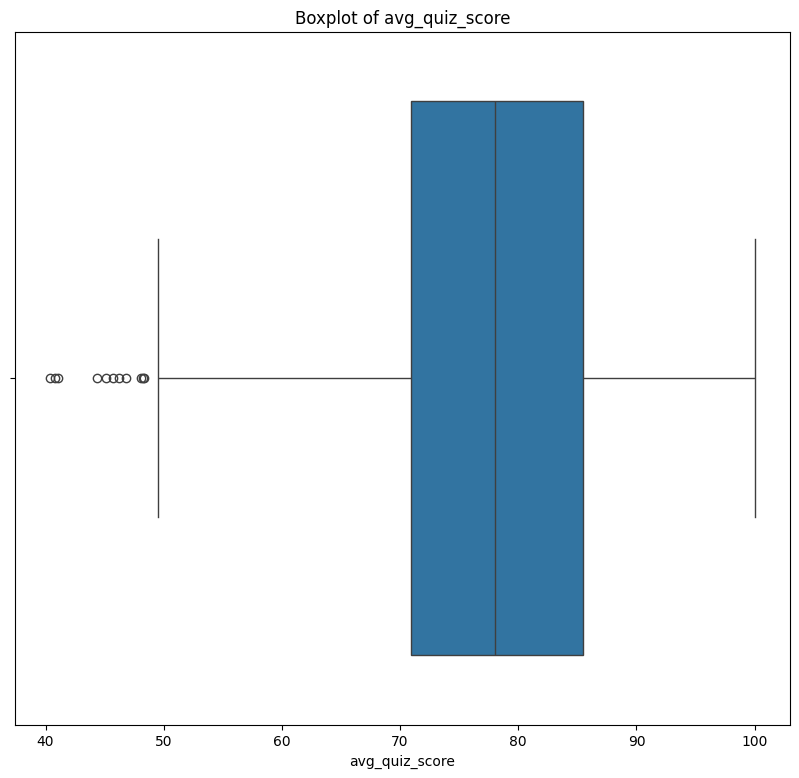

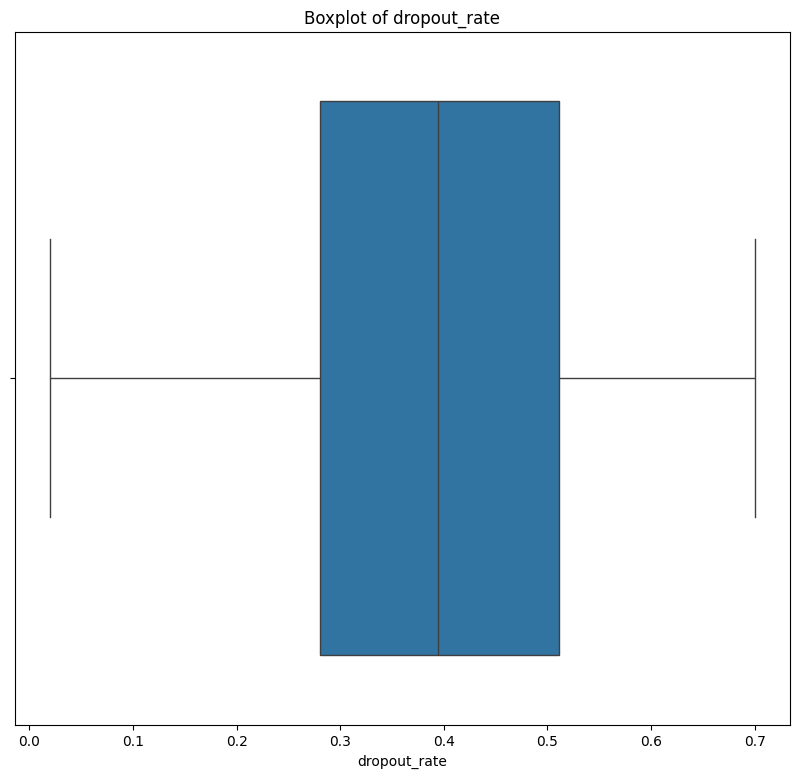

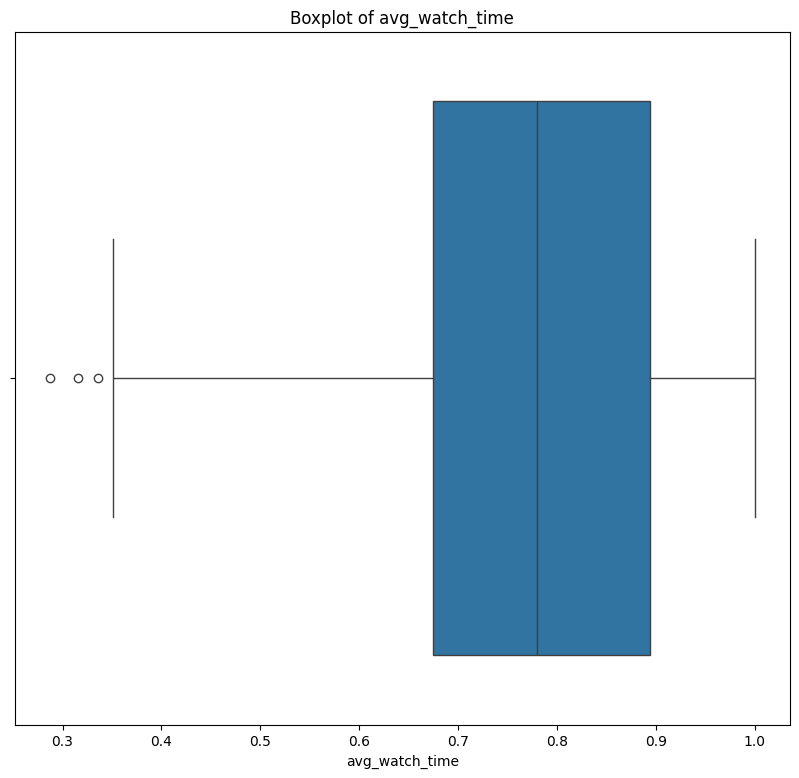

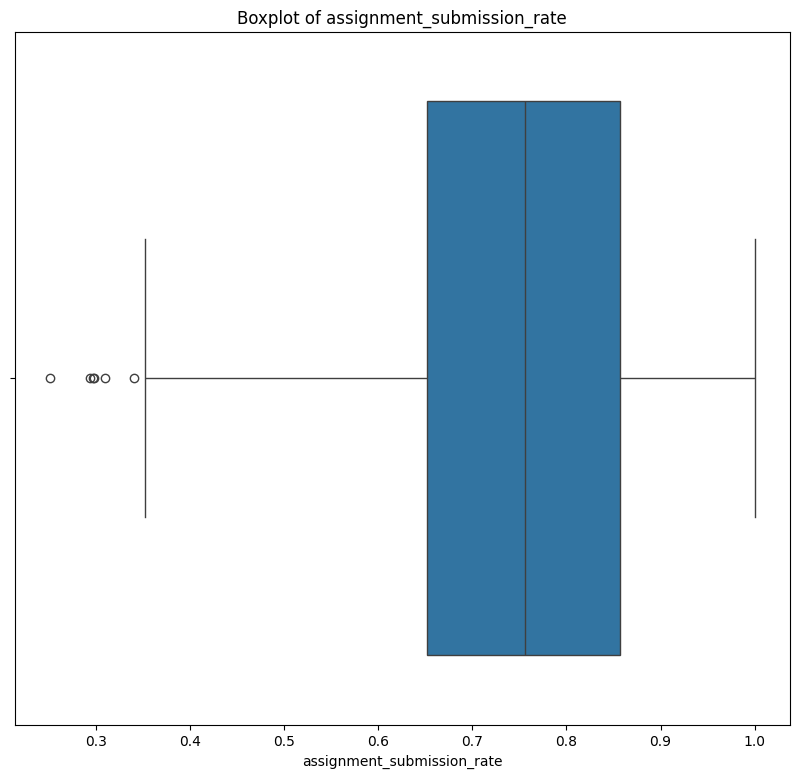

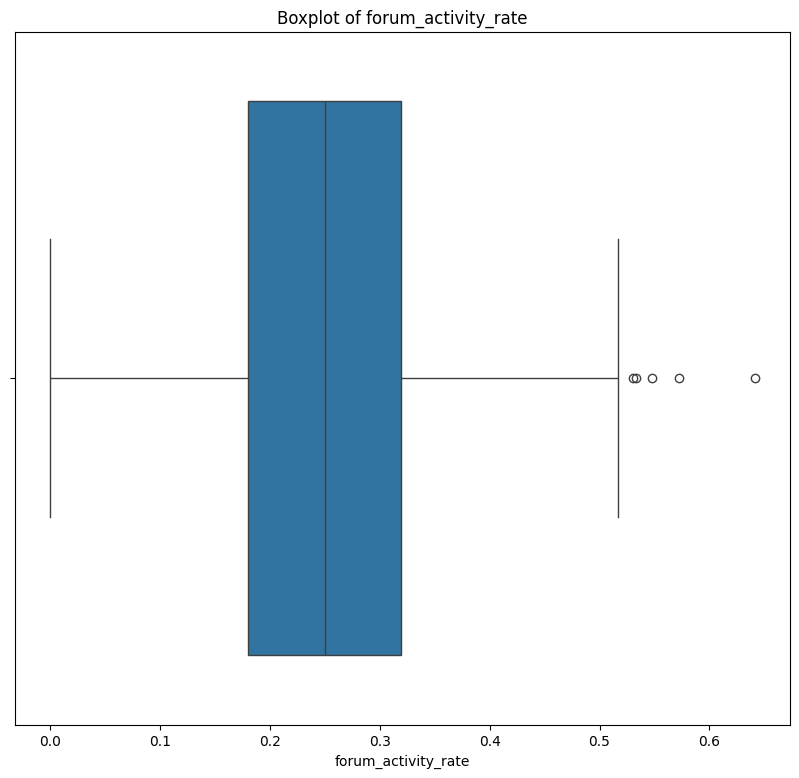

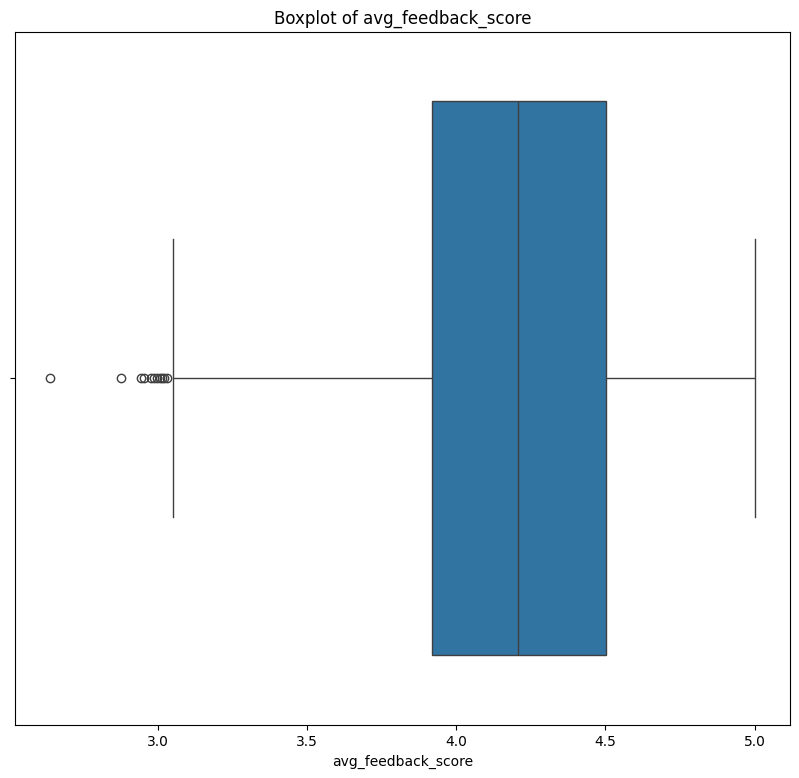

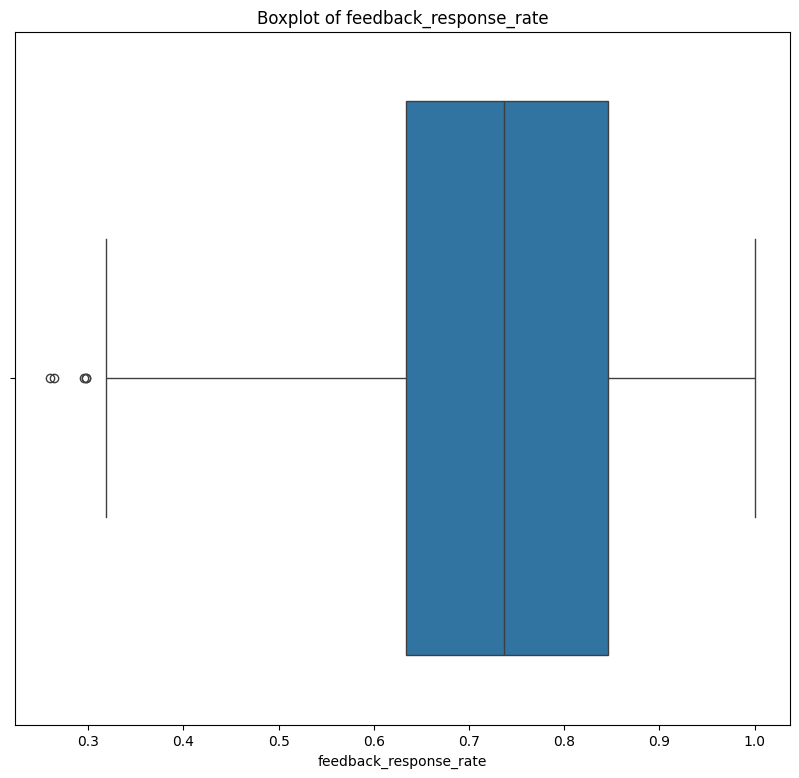

In [ ]:
for i in numerical_columns:
  plt.figure(figsize = (10,9))
  sns.boxplot(x= df[i])
  plt.title(f"Boxplot of {i}")
  plt.show()

## Boxplot Observations

The boxplots were examined to identify the spread of the numerical variables and potential outliers.

Most variables show variation across course batches. Some variables contain observations that lie outside the typical range, which may represent potential outliers.

These observations were considered during preprocessing and modeling. Since an outlier may represent a genuine batch characteristic, values were not removed solely based on the boxplot.


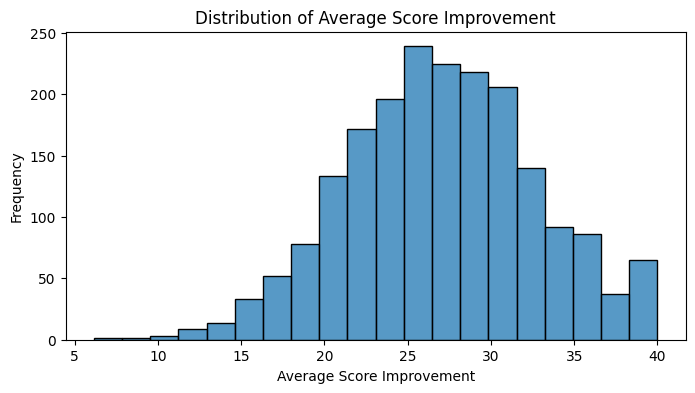

In [ ]:
plt.figure(figsize=(8,4))

sns.histplot(df['avg_score_improvement'], bins=20)

plt.title("Distribution of Average Score Improvement")
plt.xlabel("Average Score Improvement")
plt.ylabel("Frequency")

plt.show()

### Observation

The distribution of `avg_score_improvement` is concentrated mainly between approximately 20 and 33, with the highest frequency around the mid-to-high 20s.

The values range approximately from 5 to 40, with relatively fewer observations at the lower and higher ends.

Overall, the variable shows a reasonably continuous distribution without an obvious extreme concentration at a single value.

Since score improvement directly represents learner progress, it is considered an important candidate for measuring instructor effectiveness.

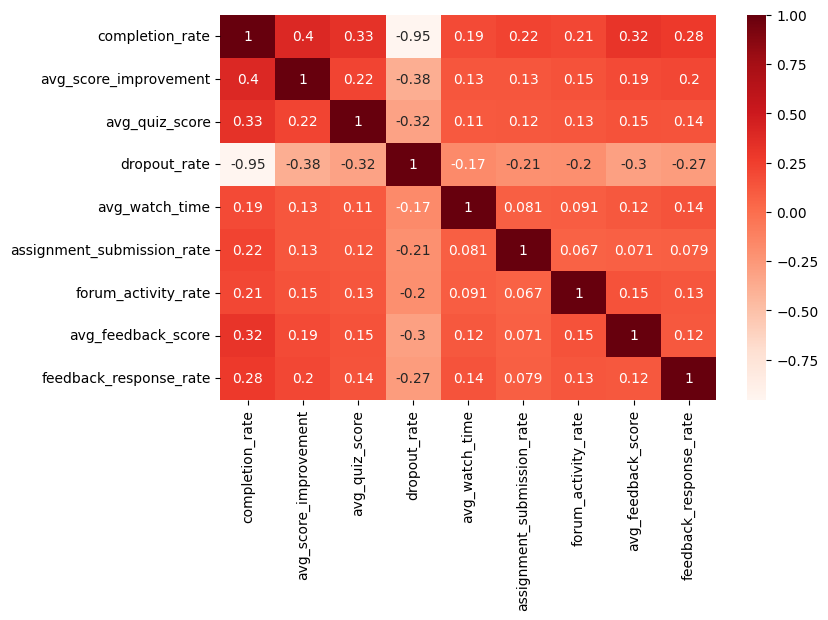

In [ ]:
plt.figure(figsize = (8,5))
sns.heatmap(df.corr(numeric_only=True),annot = True, cmap = "Reds")
plt.show()



## Correlation Analysis

A correlation heatmap is used to examine the relationships between the numerical variables in the dataset.

Correlation values range from -1 to +1.

- A value close to +1 indicates a strong positive relationship.
- A value close to -1 indicates a strong negative relationship.
- A value close to 0 indicates a weak linear relationship.

This analysis helps identify relationships between learner outcomes, engagement, and feedback variables and can support feature selection for the Instructor Effectiveness Score.

In [ ]:
df.drop_duplicates(inplace = True )

## Duplicate and Categorical Identifier Analysis

Duplicate records are checked and removed to prevent repeated batch observations from affecting the analysis.

The categorical/object columns are then identified to understand which variables contain identifiers or categorical information.

The unique values of these columns are examined to understand the number and variety of batches, instructors, and courses represented in the dataset.

### Observation

The object columns identified are `batch_id`, `instructor_id`, and `course_id`.

`batch_id` identifies individual course batches, while `instructor_id` identifies instructors and `course_id` identifies the courses being taught.

The presence of multiple records for the same instructor is expected because an instructor can teach multiple batches. Therefore, `instructor_id` will be important later when aggregating batch-level data to the instructor level.

The identifier columns are not directly used as numerical predictors because their values represent identities rather than measurable instructor performance.

In [ ]:
object_cols = df.select_dtypes(include='object').columns

print(object_cols)



Index(['batch_id', 'instructor_id', 'course_id'], dtype='object')


In [ ]:
# See the unique values

for col in object_cols:

    unique_values = df[col].unique()

    print(f"Unique values in column '{col}':")

    print(unique_values)




Unique values in column 'batch_id':
['B_1861' 'B_0354' 'B_1334' ... 'B_0861' 'B_1460' 'B_1127']
Unique values in column 'instructor_id':
['I_044' 'I_119' 'I_050' 'I_024' 'I_001' 'I_026' 'I_082' 'I_009' 'I_114'
 'I_038' 'I_007' 'I_064' 'I_105' 'I_084' 'I_087' 'I_086' 'I_088' 'I_033'
 'I_032' 'I_117' 'I_111' 'I_039' 'I_100' 'I_018' 'I_021' 'I_085' 'I_010'
 'I_055' 'I_112' 'I_113' 'I_047' 'I_090' 'I_107' 'I_052' 'I_065' 'I_103'
 'I_096' 'I_028' 'I_045' 'I_115' 'I_079' 'I_027' 'I_092' 'I_110' 'I_020'
 'I_074' 'I_118' 'I_035' 'I_101' 'I_109' 'I_097' 'I_019' 'I_040' 'I_029'
 'I_075' 'I_036' 'I_002' 'I_043' 'I_025' 'I_013' 'I_023' 'I_071' 'I_081'
 'I_062' 'I_116' 'I_072' 'I_066' 'I_016' 'I_017' 'I_069' 'I_057' 'I_060'
 'I_098' 'I_034' 'I_014' 'I_058' 'I_046' 'I_059' 'I_022' 'I_041' 'I_011'
 'I_005' 'I_089' 'I_070' 'I_094' 'I_093' 'I_091' 'I_108' 'I_095' 'I_051'
 'I_080' 'I_063' 'I_102' 'I_012' 'I_106' 'I_068' 'I_048' 'I_003' 'I_077'
 'I_015' 'I_004' 'I_037' 'I_031' 'I_073' 'I_053' 'I_049' 'I_

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for col in object_cols:

    df[col] = label_encoder.fit_transform(df[col])

df.head()


,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,1860,43,0,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,353,118,5,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,1333,49,2,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,905,23,20,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,1289,0,7,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710




## Definition

Instructor effectiveness is defined as the ability of an instructor to support learner completion, learning improvement, engagement, and positive learner feedback.

To represent these different aspects, I selected the following metrics:

### Learner Outcomes

* `completion_rate`
* `avg_score_improvement`
* `avg_quiz_score`

### Engagement

* `avg_watch_time`
* `assignment_submission_rate`
* `forum_activity_rate`

### Feedback

* `avg_feedback_score`
* `feedback_response_rate`

The `dropout_rate` is also considered because a lower dropout rate indicates better learner retention.

## Feature Direction

Most selected metrics have a positive relationship with effectiveness, meaning a higher value indicates better performance.

However, `dropout_rate` has the opposite direction because a lower dropout rate is desirable.

Therefore, the dropout score is reversed during normalization so that higher normalized values consistently represent better instructor effectiveness.

## Normalization

The selected variables have different numerical ranges. For example, feedback scores are measured on a 1–5 scale, while several other variables are fractions between 0 and 1.

Min-Max normalization is therefore used to convert the selected variables to a common 0–1 scale.

## Score Calculation

The normalized metrics are combined to create an overall Instructor Effectiveness Score.

The score is intended to provide a balanced representation of learner outcomes, engagement, and feedback rather than relying on a single metric.

The weighting assumes that these dimensions contribute equally because there is no predefined business weighting provided in the assignment.


In [ ]:
from sklearn.preprocessing import MinMaxScaler


higher_better = [
    'completion_rate',
    'avg_score_improvement',
    'avg_quiz_score',
    'avg_watch_time',
    'assignment_submission_rate',
    'forum_activity_rate',
    'avg_feedback_score',
    'feedback_response_rate'
]


lower_better = [
    'dropout_rate'
]

scaler = MinMaxScaler()


df[higher_better] = scaler.fit_transform(df[higher_better])


df[lower_better] = scaler.fit_transform(df[lower_better])

df['dropout_rate'] = 1 - df['dropout_rate']

all_metrics = higher_better + lower_better

df['effectiveness_score'] = df[all_metrics].mean(axis=1)

df['effectiveness_score'] = df['effectiveness_score'] * 100


df['effectiveness_tier'] = pd.qcut(
    df['effectiveness_score'],
    q=3,
    labels=['Low', 'Medium', 'High']
)


print(df[['effectiveness_score', 'effectiveness_tier']].head())

   effectiveness_score effectiveness_tier
0            36.577257                Low
1            60.115801             Medium
2            43.627484                Low
3            65.313512               High
4            64.103281               High


In [ ]:
print(df['effectiveness_tier'].value_counts())

effectiveness_tier
Low       667
High      667
Medium    666
Name: count, dtype: int64


In [ ]:
print(df[['effectiveness_score', 'effectiveness_tier']].describe())

       effectiveness_score
count          2000.000000
mean             57.737452
std              10.921179
min              19.083412
25%              50.276403
50%              57.952767
75%              64.902765
max              91.288751


In [ ]:
instructor_df = df.groupby('instructor_id').agg({
    'completion_rate': 'mean',
    'avg_score_improvement': 'mean',
    'avg_quiz_score': 'mean',
    'dropout_rate': 'mean',
    'avg_watch_time': 'mean',
    'assignment_submission_rate': 'mean',
    'forum_activity_rate': 'mean',
    'avg_feedback_score': 'mean',
    'feedback_response_rate': 'mean',
    'effectiveness_score': 'mean'
}).reset_index()

In [ ]:
batch_counts = df.groupby('instructor_id').size().reset_index(name='num_batches')

instructor_df = instructor_df.merge(batch_counts, on='instructor_id')

In [ ]:
print(instructor_df.head())
print(instructor_df.shape)

   instructor_id  completion_rate  avg_score_improvement  avg_quiz_score  \
0              0         0.358658               0.605253        0.646055   
1              1         0.633639               0.709411        0.693645   
2              2         0.688892               0.703843        0.691192   
3              3         0.232836               0.495047        0.625592   
4              4         0.823158               0.780993        0.762270   

   dropout_rate  avg_watch_time  assignment_submission_rate  \
0      0.337363        0.672327                    0.635317   
1      0.665891        0.771799                    0.698745   
2      0.684076        0.745203                    0.705706   
3      0.224616        0.709681                    0.677277   
4      0.815098        0.785317                    0.835679   

   forum_activity_rate  avg_feedback_score  feedback_response_rate  \
0             0.375209            0.668547                0.587682   
1             0.451731  

## Effectiveness Score Interpretation

The resulting score ranges from 0 to 1.

A higher score indicates stronger overall performance across the selected learner outcome, engagement, and feedback metrics.

The score is not treated as an absolute measure of instructor quality. It is a constructed analytical measure based on the available variables and the assumptions described above.


In [ ]:
instructor_df['effectiveness_tier'] = pd.qcut(
    instructor_df['effectiveness_score'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

In [ ]:
print(instructor_df[['effectiveness_score', 'effectiveness_tier']].head())
print(instructor_df['effectiveness_tier'].value_counts())

   effectiveness_score effectiveness_tier
0            54.293459             Medium
1            67.278582               High
2            68.823083               High
3            50.558399                Low
4            74.369222               High
effectiveness_tier
Low       40
Medium    40
High      40
Name: count, dtype: int64


In [ ]:
y = instructor_df['effectiveness_tier']

In [ ]:
X = instructor_df.drop(columns=['instructor_id', 'effectiveness_score', 'effectiveness_tier'])

In [ ]:
print(X.shape)
print(y.shape)

print(X.head())
print(y.head())

(120, 10)
(120,)
   completion_rate  avg_score_improvement  avg_quiz_score  dropout_rate  \
0         0.358658               0.605253        0.646055      0.337363   
1         0.633639               0.709411        0.693645      0.665891   
2         0.688892               0.703843        0.691192      0.684076   
3         0.232836               0.495047        0.625592      0.224616   
4         0.823158               0.780993        0.762270      0.815098   

   avg_watch_time  assignment_submission_rate  forum_activity_rate  \
0        0.672327                    0.635317             0.375209   
1        0.771799                    0.698745             0.451731   
2        0.745203                    0.705706             0.462047   
3        0.709681                    0.677277             0.352917   
4        0.785317                    0.835679             0.520220   

   avg_feedback_score  feedback_response_rate  num_batches  
0            0.668547                0.587682     

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)





(96, 10)
(24, 10)
(96,)
(24,)


# Step 3: Aggregate Batch Data to Instructor Level

The original dataset is at the batch level, but the objective is to estimate instructor effectiveness.

Since an instructor may teach multiple batches, batch-level observations are aggregated by `instructor_id`.

For continuous performance, engagement, and feedback metrics, the mean is used to represent the instructor's typical performance across their batches.

The mean is appropriate because it prevents one individual batch from completely determining the instructor-level result.

The number of batches taught by each instructor is also considered because instructors with very few batches have less historical evidence than instructors with many batches.


## Instructor-Level Aggregation

Since an instructor may teach multiple batches, the batch-level data was aggregated to the instructor level using the mean of the numerical performance metrics.

The mean was selected because it represents the instructor's typical performance across the batches they taught. It also prevents a single batch from determining the instructor's overall effectiveness.

Using the mean allows each batch to contribute to the instructor-level profile while maintaining the original scale of the performance indicators.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
df_compare = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

print(df_compare.head())



    Actual Predicted
44     Low       Low
47    High    Medium
4     High      High
55    High      High
26  Medium    Medium


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Baseline Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Baseline Accuracy: 0.9166666666666666

Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.86      0.92         7
         Low       0.83      1.00      0.91         5
      Medium       0.92      0.92      0.92        12

    accuracy                           0.92        24
   macro avg       0.92      0.92      0.92        24
weighted avg       0.92      0.92      0.92        24


Confusion Matrix:
[[ 6  0  1]
 [ 0  5  0]
 [ 0  1 11]]


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 15],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='f1_macro')

In [ ]:
print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score:
0.8883671883671884


In [ ]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

Tuned Accuracy: 0.9166666666666666

Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.86      0.92         7
         Low       0.83      1.00      0.91         5
      Medium       0.92      0.92      0.92        12

    accuracy                           0.92        24
   macro avg       0.92      0.92      0.92        24
weighted avg       0.92      0.92      0.92        24


Confusion Matrix:
[[ 6  0  1]
 [ 0  5  0]
 [ 0  1 11]]


# Mandatory Analysis Questions

## 1. Which features most influenced instructor effectiveness, and why?

The most influential features were identified using the feature importance results from the trained machine learning model.

Features related to learner outcomes, such as completion rate, score improvement, and quiz performance, are important because they provide direct information about learner progress and course outcomes.

Engagement-related features such as watch time, assignment submission rate, and forum activity provide information about learner participation.

Feedback-related features such as average feedback score and feedback response rate provide information about learner perception and interaction with the course.

The importance of individual features should be interpreted as the model's reliance on those variables for prediction, rather than as proof that a feature directly causes instructor effectiveness.


## 2. Which variables could be misleading or confounded?

Some variables may be influenced by factors other than the instructor.

For example, dropout rate may depend on course difficulty, learner motivation, personal circumstances, workload, or scheduling. Therefore, a high dropout rate does not necessarily mean that the instructor was ineffective.

Similarly, average feedback score may be affected by course content, platform experience, learner expectations, or factors unrelated to the instructor.

Score improvement and quiz scores can also depend on learners' prior knowledge and the difficulty of assessments.

Engagement measures such as watch time, assignment submission rate, and forum activity may depend on learner motivation and course design as well as instructor behavior.

Therefore, these variables should be interpreted as indicators of instructor effectiveness rather than perfect measures of instructor performance.

## 3. How could this model fail in real-world usage?

The model may not perform equally well when applied to data that differs from the data used during training.

Different courses may have different levels of difficulty, teaching formats, assessment methods, and learner expectations. Therefore, the same effectiveness score may not have exactly the same meaning across different courses.

The model may also perform differently for learner populations with different levels of prior knowledge, motivation, or engagement.

Another limitation is the size of the available data. If there are relatively few instructors or batches, the model may not learn all possible patterns and may not generalize well to new instructors.

The effectiveness tier is also a constructed target based on selected metrics and assumptions. Therefore, the model is primarily learning to predict the defined effectiveness tiers rather than an independently measured concept of instructor quality.

The model may also become less reliable if learner behavior, course structure, or teaching methods change over time. This is known as a change in the data distribution.

Finally, some important instructor characteristics may not be represented in the available dataset. As a result, the model cannot account for every factor that may influence learner outcomes.

## 4. What additional data would you want to improve this analysis?

Additional information could make the analysis more reliable and help separate instructor effects from other factors.

Useful additional data could include:

- Course difficulty level
- Learner prior knowledge or pre-course assessment performance
- Learner attendance
- Class or batch size
- Instructor teaching experience
- Instructor experience with the specific course
- Course duration
- Number of instructor-learner interactions
- Response time to learner questions
- Assignment and assessment difficulty
- Qualitative learner feedback or comments
- Historical instructor performance

These additional variables could provide more context and help distinguish instructor-related effects from course-related and learner-related factors.

## 5. Should this model be used for instructor performance evaluation? Why or why not?

This model should not be used as the sole basis for evaluating instructor performance.

The model can be useful as a supporting analytical tool for identifying patterns in learner outcomes, engagement, and feedback. For example, it could help an EdTech organization identify instructors or batches that may require further investigation or support.

However, the model is based only on the variables available in the dataset, and some of those variables may be influenced by factors outside the instructor's control.

In addition, the effectiveness score itself is constructed using assumptions about which metrics represent instructor effectiveness. Therefore, the resulting tier should not be treated as a definitive judgment of an instructor.

A better approach would be to combine model results with course context, learner characteristics, qualitative feedback, instructor experience, and human review before making important decisions about instructor performance.

Therefore, the model is more appropriate as a decision-support tool rather than an automatic instructor evaluation system.

## Limitations of Model Accuracy

The final model achieved an accuracy of 91.67% on the test set. However, accuracy alone does not provide a complete evaluation of the model.

The test set contains 24 observations, so a small number of incorrect predictions can noticeably change the accuracy.

Therefore, precision, recall, F1-score, and the confusion matrix are also considered when evaluating the model.

The model's performance should also be validated on a larger and more representative dataset before being considered for real-world deployment.

### Modeling Consideration

The effectiveness tiers were defined using learner outcome, engagement, and feedback metrics available in the dataset. These same instructor-level metrics were then used as features for the classification model.

As a result, the model evaluates how well the selected features can reproduce the defined effectiveness tiers. Therefore, the reported accuracy should be interpreted within the context of this scoring framework rather than as an independent measure of instructor effectiveness.

For real-world deployment, the model should be validated using additional independent evidence and a larger, more representative dataset.